In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch torchvision gradio ranger-adabelief

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install ranger-adabelief --no-cache-dir


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import gradio as gr
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from ranger_adabelief.ranger_adabelief import RangerAdaBelief


Load and Preprocess the Dataset


In [ ]:
data_dir = "/content/drive/MyDrive/dataset-20250312T092914Z-001/dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")


Train: 2272, Val: 486, Test: 488


Define a Unique High-Accuracy Model


In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch, channels, _, _ = x.size()
        y = self.global_avg_pool(x).view(batch, channels)
        y = self.fc(y).view(batch, channels, 1, 1)
        return x * y

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(nn.functional.softplus(x))

class CustomAlexNet(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomAlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.BatchNorm2d(64),
            Mish(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            SEBlock(64),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.BatchNorm2d(192),
            Mish(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            SEBlock(192),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            Mish(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            Mish(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            Mish(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            SEBlock(256)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            Mish(),
            nn.Dropout(0.5),
            nn.Linear(4096, 1024),
            Mish(),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomAlexNet(num_classes=4).to(device)


Define Loss Function & Optimizer

In [ ]:
!pip install torch_optimizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 6.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim  # <- This is PyTorch's built-in optimizer library
import torch_optimizer  # <- This is for using Ranger

criterion = nn.CrossEntropyLoss()
optimizer = torch_optimizer.Ranger(model.parameters(), lr=0.0001, weight_decay=1e-5)

# ✅ Corrected Import for lr_scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torch.cuda.amp as amp  # ✅ Mixed Precision
import time

# ✅ Use AMP for Faster Training
scaler = amp.GradScaler()

# ✅ Move model to GPU and enable JIT compilation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.jit.script(model).to(device)  # JIT Compilation for Speed

# ✅ Use AdamW (better than RAdam)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-5)

# ✅ Cosine Annealing + Warm Restarts for Better Learning Rate Scheduling
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

# ✅ Enable Efficient Data Loading
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ✅ Increase Epochs for Better Accuracy
num_epochs = 20
train_losses, val_losses = [], []

print("🚀 Training Started...")

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=True)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # ✅ Mixed Precision Training (Speeds up Training)
        with amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # ✅ Scale loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ✅ Validation Step
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%, Time: {time.time()-start_time:.2f}s")

    scheduler.step()

print("✅ Training Complete! 🚀 Model is Ready.")


<ipython-input-10-eea14b3ed33b>:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


🚀 Training Started...


  0%|          | 0/36 [00:00<?, ?it/s]<ipython-input-10-eea14b3ed33b>:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
Epoch [1/20]: 100%|██████████| 36/36 [04:07<00:00,  6.87s/it, acc=55.4, loss=0.624]


Epoch 1: Train Loss: 1.0076, Val Loss: 0.9197, Val Acc: 60.49%, Time: 295.05s


Epoch [2/20]: 100%|██████████| 36/36 [00:58<00:00,  1.62s/it, acc=68.8, loss=0.59]


...

Epoch 18: Train Loss: 0.2702, Val Loss: 0.4758, Val Acc: 85.80%, Time: 68.61s


Epoch [19/20]: 100%|██████████| 36/36 [00:56<00:00,  1.58s/it, acc=90.7, loss=0.131]


Epoch 19: Train Loss: 0.2470, Val Loss: 0.5483, Val Acc: 79.84%, Time: 69.48s


Epoch [20/20]: 100%|██████████| 36/36 [00:57<00:00,  1.59s/it, acc=90.8, loss=0.263]


Epoch 20: Train Loss: 0.2421, Val Loss: 0.2427, Val Acc: 89.51%, Time: 69.73s
✅ Training Complete! 🚀 Model is Ready.


In [ ]:
import gradio as gr
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

# ✅ Load Model & Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()  # Set to evaluation mode

# ✅ Define Image Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ✅ Class Labels (Update these with your dataset's classes)
class_labels = ["Benign", "Malignant Early Pre-B", "Malignant Pre-B", "Malignant Pro-B"]

# ✅ Define Prediction Function
def predict_image(img):
    img = Image.fromarray(img).convert("RGB")  # Convert numpy array to PIL Image
    img = transform(img).unsqueeze(0).to(device)  # Preprocess & add batch dim

    with torch.no_grad():
        output = model(img)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

    return {class_labels[i]: float(probabilities[0][i]) for i in range(len(class_labels))}

# ✅ Create Gradio Interface
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(),
    title="🔬 Blood Cancer Prediction",
    description="Upload a blood smear image to predict if it's benign or malignant.",
    live=True
)

# ✅ Launch Gradio App
interface.launch(share=True)  # Use `share=True` to get a public link


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dd271bec07546f6318.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


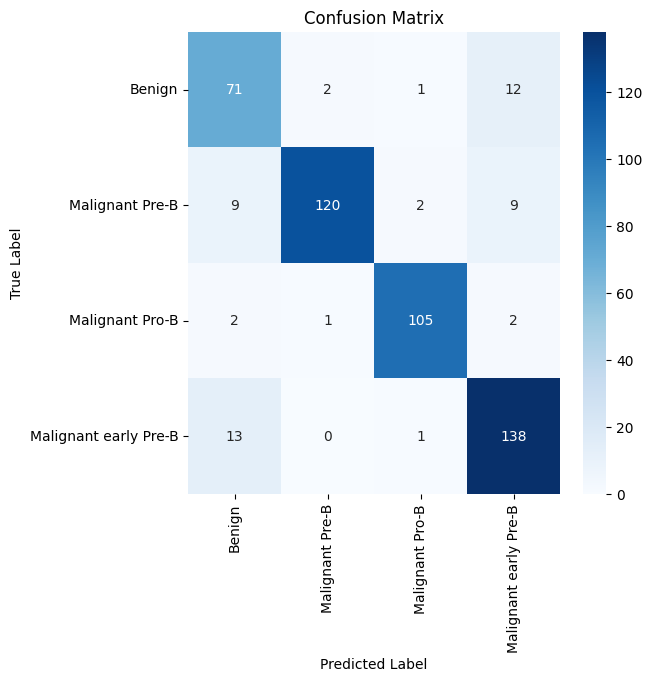

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Move model to evaluation mode
model.eval()

# Initialize lists to store predictions and true labels
all_preds = []
all_labels = []

# Run inference on the test set
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = dataset.classes  # Get class names from ImageFolder

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


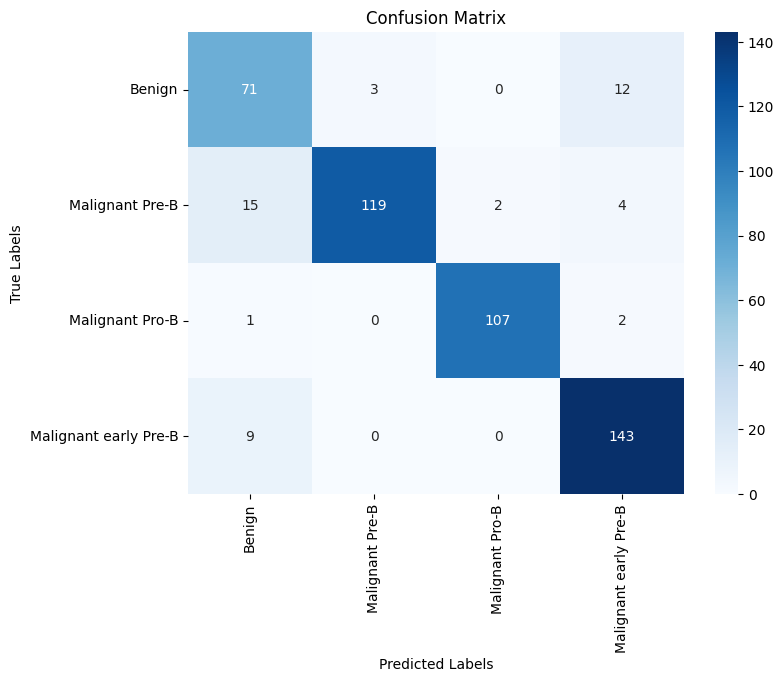

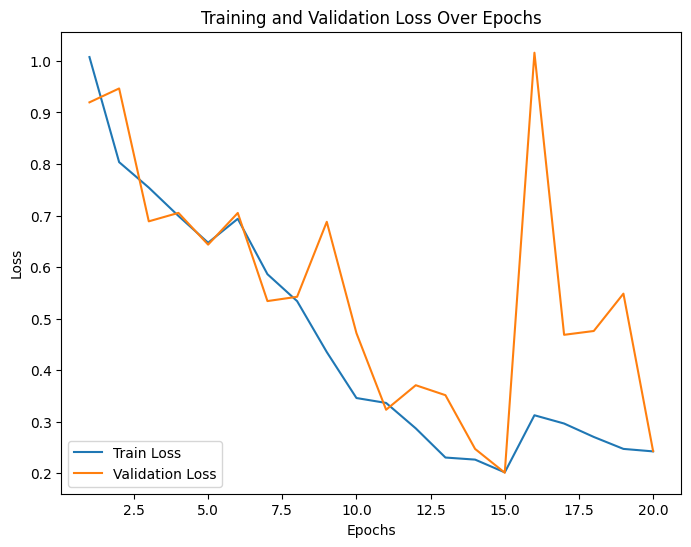

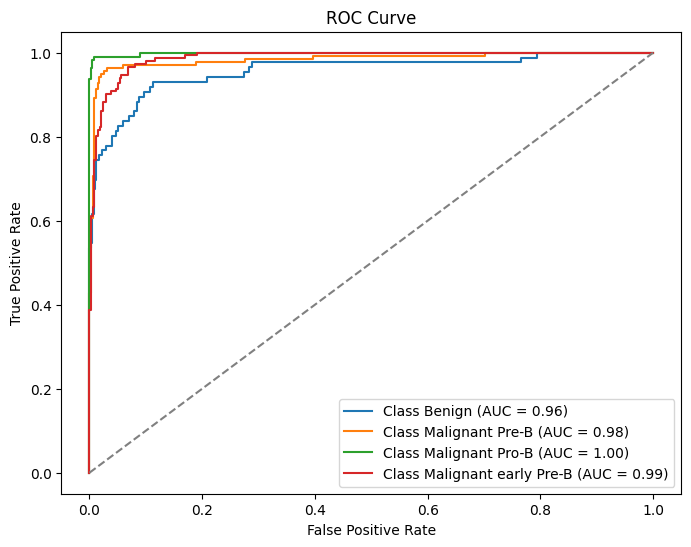

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Assuming test_loader and model are defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect true labels and predictions
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

class_names = dataset.classes  # Extract class names from dataset

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# 2. Accuracy Over Epochs
plt.figure(figsize=(8, 6))
epochs = range(1, len(train_losses) + 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.show()

# 3. ROC Curve (for each class)
plt.figure(figsize=(8, 6))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
